In [8]:
# Plot distance to filament vs sigma 5


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.cosmology import Planck18 as cosmo
from astropy import units as u
from astropy.table import Table
from scipy.stats import pearsonr

# Load data
gxs = pd.read_csv('../data/sdss_dr72safe0_sigma_3.0.csv')
z_mask = (gxs['red'] > 0.07) & (gxs['red'] < 0.2)
gxs = gxs[z_mask]
gxs = gxs[gxs['mag_abs_r'] < -21.2]


In [9]:

# Print z range
print('Redshift range: {:.3f} - {:.3f}'.format(gxs['red'].min(), gxs['red'].max()))

# Print columns
print('Columns:', gxs.columns)

Redshift range: 0.070 - 0.200
Columns: Index(['indx', 'sector', 'mregion', 'ra', 'dec', 'cz', 'fgotten',
       'selection_fn', 'mag_abs_u', 'mag_abs_g', 'mag_abs_r', 'mag_abs_i',
       'mag_abs_z', 'mu_50', 'r50_r90', 'red', 'gr', 'lum_g', 'lum_r', 'x',
       'y', 'z', 'idnode', 'typenode', 'dist_node', 'idfil', 'idseg',
       'long_fil', 'long_seg', 'lum_r_fil', 'lum_r_seg', 'dist_fil'],
      dtype='object')


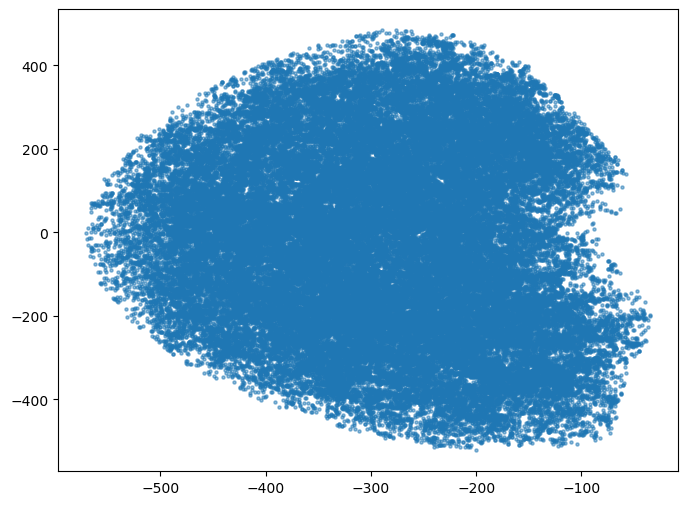

In [10]:
# Plot x vs y
plt.figure(figsize=(8, 6))
plt.scatter(gxs['x'], gxs['y'], s=5, alpha=0.5)
plt.show()

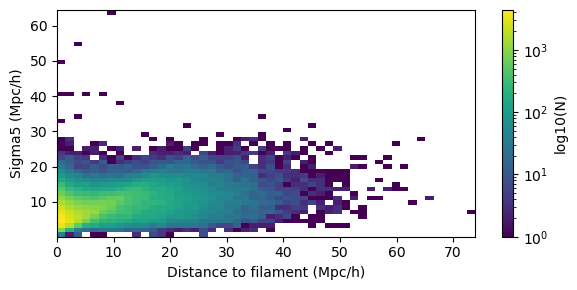

/tmp/ipykernel_4225/3034416807.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bin_stats = gxs.groupby('sigma5_bin', observed=False).apply(


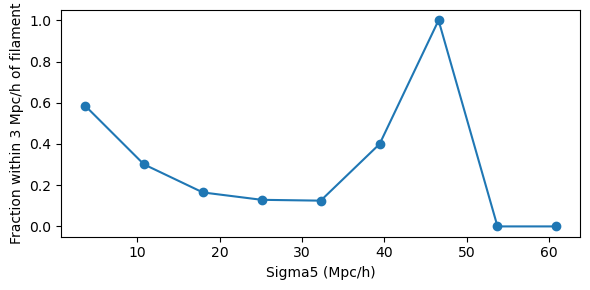

In [11]:
# Calculate sigma5:= the distance to the 5th nearest neighbor

nearest_neighbor_n = 5
# Use CKDTree for efficient neighbor search
# We will use the ['x', 'y', 'z'] columns for 3D positions
from scipy.spatial import cKDTree
positions = gxs[['x', 'y', 'z']].values
tree = cKDTree(positions)
# Query the tree for the 5 nearest neighbors (k=6 because the first neighbor is the point itself)
distances, indices = tree.query(positions, k=nearest_neighbor_n + 1)
# The distance to the 5th nearest neighbor is the 5th entry in the distances array (index 4)
gxs['sigma5'] = distances[:, nearest_neighbor_n-1]
# Plot distance to filament vs sigma5 with a lognormal 2d histogram
import matplotlib.pyplot as plt
# Option 1: using norm='log'
plt.figure(figsize=(6, 3))
plt.hist2d(gxs['dist_fil'], gxs['sigma5'], bins=50, norm='log', cmap='viridis')
plt.colorbar(label='log10(N)')
plt.xlabel('Distance to filament (Mpc/h)')
plt.ylabel(f'Sigma{nearest_neighbor_n} (Mpc/h)')
plt.tight_layout()
plt.savefig(f'../plots/dist_fil_vs_sigma{nearest_neighbor_n}.png', dpi=100)
plt.show()


# How many galaxies are within 3 Mpc/h of a filament for a given sigma5?
# Let's fix sigma5 bins and calculate the fraction of galaxies within 3 Mpc/h of a filament in each bin
# Define bins and bin centers
sigma5_bins = np.linspace(gxs['sigma5'].min(), gxs['sigma5'].max(), 10)
bin_centers = (sigma5_bins[:-1] + sigma5_bins[1:]) / 2

# Assign bins (categorical), ensure all bins are kept in the groupby
gxs['sigma5_bin'] = pd.cut(gxs['sigma5'], bins=sigma5_bins)

# Compute fraction per bin, including empty bins (observed=False)
bin_stats = gxs.groupby('sigma5_bin', observed=False).apply(
    lambda df: np.mean(df['dist_fil'] < 3)
)

# Plot with bin centers
plt.figure(figsize=(6, 3))
plt.plot(bin_centers, bin_stats, marker='o')
plt.xlabel('Sigma5 (Mpc/h)')
plt.ylabel('Fraction within 3 Mpc/h of filament')
plt.tight_layout()

# Ensure the directory exists before saving
import os
os.makedirs('../plots', exist_ok=True)
plt.savefig('../plots/frac_within_3mpc_vs_sigma5.png', dpi=100)
plt.show()



/tmp/ipykernel_4225/14274000.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bin_stats = gxs.groupby('sigma_bin', observed=False).apply(
/tmp/ipykernel_4225/14274000.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bin_stats = gxs.groupby('sigma_bin', observed=False).apply(
/tmp/ipykernel_4225/14274000.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior

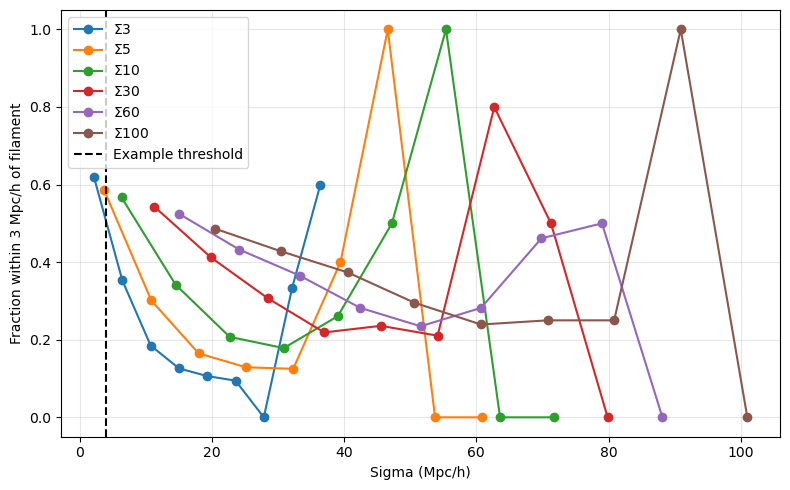

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import os

# ----------------------------------------------------------------------
# 1. Prepare data
positions = gxs[['x', 'y', 'z']].values
tree = cKDTree(positions)

# List of nearest neighbor numbers to analyse
nn_list = [3, 5,10, 30, 60, 100]   # you can add more

# Determine the maximum k needed (largest nn + 1 because point itself is included)
max_k = max(nn_list) + 1

# Query once for the maximum k, then extract distances for each n
# This is much faster than building a new KDTree for each n.
distances, indices = tree.query(positions, k=max_k)

# Ensure output directory exists
os.makedirs('../plots', exist_ok=True)

# ----------------------------------------------------------------------
# 2. Loop over nearest neighbor values
for nn in nn_list:
    # Sigma_n is the distance to the nn-th nearest neighbor
    # Indexing: distances[:, nn-1] because distances[:,0] is the point itself
    sigma_col = f'sigma{nn}'
    gxs[sigma_col] = distances[:, nn-1]
    
    # ----- Plot 2D histogram: distance to filament vs sigma_n -----
    plt.figure(figsize=(6, 3))
    plt.hist2d(gxs['dist_fil'], gxs[sigma_col], bins=50, norm='log', cmap='viridis')
    plt.colorbar(label='log10(N)')
    plt.xlabel('Distance to filament (Mpc/h)')
    plt.ylabel(f'Sigma{nn} (Mpc/h)')
    plt.tight_layout()
    plt.savefig(f'../plots/dist_fil_vs_sigma{nn}.png', dpi=100)
    plt.close()   # close to avoid memory buildup
    
    # ----- Fraction of galaxies within 3 Mpc/h of filament vs sigma_n bins -----
    # Create bins for sigma_n (10 bins covering the full range)
    sigma_bins = np.linspace(gxs[sigma_col].min(), gxs[sigma_col].max(), 10)
    bin_centers = (sigma_bins[:-1] + sigma_bins[1:]) / 2
    
    gxs['sigma_bin'] = pd.cut(gxs[sigma_col], bins=sigma_bins)
    bin_stats = gxs.groupby('sigma_bin', observed=False).apply(
        lambda df: np.mean(df['dist_fil'] < 3)
    )
    
    plt.figure(figsize=(6, 3))
    plt.plot(bin_centers, bin_stats, marker='o')
    plt.xlabel(f'Sigma{nn} (Mpc/h)')
    plt.ylabel('Fraction within 3 Mpc/h of filament')
    plt.tight_layout()
    plt.savefig(f'../plots/frac_within_3mpc_vs_sigma{nn}.png', dpi=100)
    plt.close()
    
    # Optional: store bin_centers and bin_stats for later combined plot
    # (We'll do that in a dictionary for the combined figure)
    if nn == nn_list[0]:
        # initialize storage
        frac_data = {}
    frac_data[nn] = (bin_centers, bin_stats)

# ----------------------------------------------------------------------
# 3. Combined plot: fraction vs sigma_n for all n on one figure
plt.figure(figsize=(8, 5))
for nn, (centers, stats) in frac_data.items():
    plt.plot(centers, stats, marker='o', label=fr'$\Sigma${nn}')
plt.axvline(x=4, color='k', linestyle='--', label='Example threshold')

plt.xlabel('Sigma (Mpc/h)')
plt.ylabel('Fraction within 3 Mpc/h of filament')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/frac_within_3mpc_vs_sigma_combined.png', dpi=100)
plt.show()